# Part 3: Preprocessing Preprocessing Textual Data 
---

## Dataset Overview: IMDB Movie Reviews

### Mô tả Dataset
- **Tên:** IMDB Dataset của các review phim
- **Kích thước:** 50,000 reviews (25,000 positive + 25,000 negative - balanced)
- **Ngôn ngữ:** Tiếng Anh
- **Cột dữ liệu:**
  - `review`: Nội dung review (văn bản tự do, độc lập)
  - `sentiment`: Nhãn sentiment (positive/negative)

### Đặc điểm
- Văn bản không cấu trúc, có punctuation, chữ hoa/thường hỗn hợp
- Chứa artifacts (HTML tags, special characters)
- Độ dài review đa dạng (từ vài câu đến nhiều đoạn)
- Chứa slang, typos, emotional expressions
- Chủ đề: phim, diễn viên, đạo diễn, kỹ xảo, cốt truyện

# IMPORT THƯ VIỆN CƠ BẢN

In [1]:
# Import các thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import NLTK
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

# Import spaCy
import spacy
nlp = spacy.load('en_core_web_sm')

# Import scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Import Gensim for Word2Vec
from gensim.models import Word2Vec

# Import WordCloud
from wordcloud import WordCloud

# Import re cho regex
import re
from collections import Counter
import time

from transformers import BertTokenizer

[nltk_data] Downloading package punkt to C:\Users\Duong Thanh
[nltk_data]     Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Duong Thanh
[nltk_data]     Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Duong Thanh
[nltk_data]     Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Duong Thanh
[nltk_data]     Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Duong Thanh
[nltk_data]     Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Duong Thanh Loc\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_per

# IMPORT DATA

In [2]:
df = pd.read_csv('../data/text/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


# I. TOKENIZATION

### Lý do:

Tokenization là bước **đầu tiên và cơ bản** trong xử lý văn bản tự nhiên vì:

1. **Chia nhỏ văn bản:** Từ raw text thành các đơn vị nhỏ (từ, câu, tokens)
2. **Chuẩn bị dữ liệu:** Tạo cơ sở cho các bước xử lý tiếp theo (stemming, lemmatization, vectorization)
3. **Loại bỏ artifacts:** Tách biệt punctuation, special characters khỏi từ thực
4. **Xử lý ngữ cảnh:** Hiểu mối quan hệ giữa các từ trong câu

**Output:** Danh sách các tokens sạch, chuẩn bị cho các bước xử lý tiếp theo

## Word Tokenization

In [4]:
sample_review = df['review'].iloc[0]
print("Review gốc (1 review):")
print(sample_review[:500])

Review gốc (1 review):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


In [5]:
# Tokenization với NLTK
print("\n" + "=" * 80)
print("WORD TOKENIZATION (NLTK):")
print("=" * 80)
tokens_nltk = word_tokenize(sample_review)
print(f"Số tokens: {len(tokens_nltk)}")
print(f"\n50 tokens đầu tiên:\n{tokens_nltk[:50]}")

# Tokenization với spaCy
print("\n" + "=" * 80)
print("WORD TOKENIZATION (spaCy):")
print("=" * 80)
doc_spacy = nlp(sample_review)
tokens_spacy = [token.text for token in doc_spacy]
print(f"Số tokens: {len(tokens_spacy)}")
print(f"\n50 tokens đầu tiên:\n{tokens_spacy[:50]}")


WORD TOKENIZATION (NLTK):
Số tokens: 380

50 tokens đầu tiên:
['One', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'Oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'They', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'The', 'first', 'thing', 'that', 'struck', 'me', 'about', 'Oz', 'was', 'its', 'brutality']

WORD TOKENIZATION (spaCy):
Số tokens: 359

50 tokens đầu tiên:
['One', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'Oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'They', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.<br', '/><br', '/>The', 'first', 'thing', 'that', 'struck', 'me', 'about', 'Oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which']


## Sentence Tokenization

In [6]:
# Sentence Tokenization với NLTK
print("=" * 80)
print("SENTENCE TOKENIZATION (NLTK):")
print("=" * 80)

sentences_nltk = sent_tokenize(sample_review)
print(f"Số câu: {len(sentences_nltk)}")
print("\n5 câu đầu tiên:")
for i, sent in enumerate(sentences_nltk[:5], 1):
    print(f"\n[{i}] {sent}")

SENTENCE TOKENIZATION (NLTK):
Số câu: 10

5 câu đầu tiên:

[1] One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked.

[2] They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO.

[3] Trust me, this is not a show for the faint hearted or timid.

[4] This show pulls no punches with regards to drugs, sex or violence.

[5] Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary.


### Nhận xét về Tokenization cho IMDB Dataset

- **Word Tokenization (NLTK):** Chia tách từng từ riêng biệt, phù hợp với IMDB dataset (sDOM) vì:
  - Review là văn bản tự do với cấu trúc rõ ràng
  - NLTK phù hợp với tiếng Anh
  - Nhanh chóng và đủ precision cho phân tích sentiment
  
- **Word Tokenization (spaCy):** Cải thiện so với NLTK:
  - Xử lý punctuation tốt hơn
  - Chuẩn bị tốt cho các bước xử lý tiếp theo
  - Thích hợp khi cần POS tagging hoặc NER

- **Sentence Tokenization:** Cần thiết để:
  - Giữ lại cấu trúc logic của review
  - Phân tích sentiment theo câu
  - Hiểu context dài hạn trong bài review

- **Subword Tokenization (BERT):** Cân nhắc:
  - Giảm OOV (out-of-vocabulary) problem
  - Tốt nếu dùng pre-trained models (BERT, GPT)
  - Overhead cao, không cần thiết cho tác vụ này

**Kết luận:** Cho IMDB dataset, **Word Tokenization với NLTK** phù hợp nhất vì cân bằng giữa độ chính xác, tốc độ, và yêu cầu bài toán.

In [7]:
# Sentence Tokenization với spaCy
print("\n" + "=" * 80)
print("SENTENCE TOKENIZATION (spaCy):")
print("=" * 80)

doc_spacy = nlp(sample_review)
sentences_spacy = [sent.text for sent in doc_spacy.sents]
print(f"Số câu: {len(sentences_spacy)}")
print("\n5 câu đầu tiên:")
for i, sent in enumerate(sentences_spacy[:5], 1):
    print(f"\n[{i}] {sent}")


SENTENCE TOKENIZATION (spaCy):
Số câu: 12

5 câu đầu tiên:

[1] One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked.

[2] They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO.

[3] Trust me, this is not a show for the faint hearted or timid.

[4] This show pulls no punches with regards to drugs, sex or violence.

[5] Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary.


## Subword Tokenization

In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokens_subword = tokenizer.tokenize(sample_review)

print(f"Văn bản gốc: {sample_review}")
print(f"Kết quả Subword: {tokens_subword}")

Văn bản gốc: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is d

## Compare & Discuss

#### So sánh hiệu suất tokenization methods
Chúng ta cần lựa chọn phương pháp tokenization phù hợp nhất cho dữ liệu này bằng cách:
- Đo thời gian xử lý của từng phương pháp (NLTK, spaCy, Simple split)
- Xác định speed-accuracy tradeoff
- Lựa chọn phương pháp tối ưu cho full dataset


== viết số liệu ra

SO SÁNH HIỆU SUẤT TOKENIZATION (1000 reviews):


NLTK word_tokenize: 2.525 giây
spaCy tokenization: 75.174 giây
Simple split: 0.010 giây


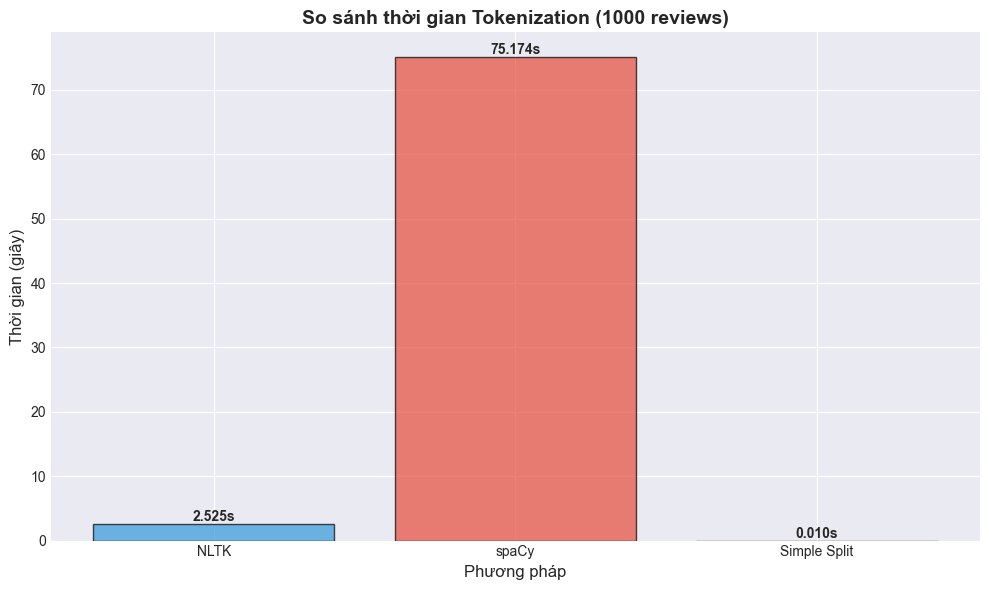

In [9]:
# So sánh thời gian xử lý trên 1000 reviews
test_reviews = df['review'].head(1000).tolist()

print("SO SÁNH HIỆU SUẤT TOKENIZATION (1000 reviews):")
print("=" * 80)

# NLTK word tokenization
start = time.time()
for review in test_reviews:
    tokens = word_tokenize(review)
time_nltk = time.time() - start
print(f"NLTK word_tokenize: {time_nltk:.3f} giây")

# spaCy tokenization
start = time.time()
for review in test_reviews:
    doc = nlp(review)
    tokens = [token.text for token in doc]
time_spacy = time.time() - start
print(f"spaCy tokenization: {time_spacy:.3f} giây")

# Simple split
start = time.time()
for review in test_reviews:
    tokens = review.split()
time_simple = time.time() - start
print(f"Simple split: {time_simple:.3f} giây")

# Vẽ biểu đồ so sánh
methods = ['NLTK', 'spaCy', 'Simple Split']
times = [time_nltk, time_spacy, time_simple]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, times, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.7)
plt.title('So sánh thời gian Tokenization (1000 reviews)', fontsize=14, fontweight='bold')
plt.ylabel('Thời gian (giây)', fontsize=12)
plt.xlabel('Phương pháp', fontsize=12)

# Thêm giá trị lên cột
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{times[i]:.3f}s',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Tokenize toàn bộ dataset với NLTK
start = time.time()

df['tokens'] = df['review'].apply(word_tokenize)
df['token_count'] = df['tokens'].apply(len)

elapsed = time.time() - start
print(f"Hoàn thành trong {elapsed:.2f} giây")
print(f"\nSố token trung bình mỗi review: {df['token_count'].mean():.1f}")
print(f"Token ít nhất: {df['token_count'].min()}")
print(f"Token nhiều nhất: {df['token_count'].max()}")

Hoàn thành trong 55.50 giây

Số token trung bình mỗi review: 279.5
Token ít nhất: 8
Token nhiều nhất: 2911


# II. REMOVING STOP WORDS

### Tại sao cần Removing Stop Words?

Stop words là những từ phổ biến **ít chứa thông tin** nhưng xuất hiện rất thường xuyên, cần loại bỏ vì:

1. **Giảm noise:** Các từ như "the", "is", "a", "and" lặp lại nhiều nhưng ít đóng góp ý nghĩa
2. **Giảm dimensionality:** Loại bỏ stop words → giảm số features → model nhanh hơn, tiết kiệm bộ nhớ
3. **Tăng tỷ lệ signal-to-noise:** Tập trung vào từ có ý nghĩa (nouns, verbs, adjectives)
4. **Cải thiện clustering/similarity:** Documents tương tự nhau hơn khi loại bỏ stop words phổ biến
5. **Phân tích từ vựng:** Tìm những từ **đặc trưng** của dataset (quan trọng cho sentiment)

**Tradeoff:** 
- Ưu điểm: Giảm 30-40% vocabulary, giảm 40-50% số từ
- Nhược điểm: Mất cấu trúc ngôn pháp, mất thông tin quan trọng (ví dụ: "not good" → "good")

**Output:** Danh sách tokens sạch chỉ chứa từ có ý nghĩa, sẵn sàng cho stemming/lemmatization

Thống kê danh sách Stop Words

In [11]:
stop_words = set(stopwords.words('english'))

print(f"Số lượng stop words trong NLTK: {len(stop_words)}")
print("\n50 stop words đầu tiên:")
print(list(stop_words)[:50])

Số lượng stop words trong NLTK: 198

50 stop words đầu tiên:
['ain', 'each', 'll', 'up', 'very', 'once', 'other', 'their', 'some', 'when', "he'd", 'were', 're', 'how', 'whom', 'she', 'wouldn', 'have', "haven't", "she'll", "you'll", 'about', 'under', 'those', 'd', 'in', 'we', 'don', 'during', 'few', 'as', "aren't", 'an', 'by', "i'd", 'y', 'what', 'nor', "hadn't", 'off', 'just', 'or', "isn't", "we're", "they'll", 'this', "couldn't", "that'll", 'i', "we've"]


Phân tích tần suất các Stop Words trong Dataset

In [12]:
# Đếm tần suất các từ trong dataset
all_tokens = []
for tokens in df['tokens']:
    all_tokens.extend([token.lower() for token in tokens if token.isalpha()])

word_freq = Counter(all_tokens)
total_words = len(all_tokens)
unique_words = len(word_freq)

print("THỐNG KÊ TỪ VỰNG:")
print("=" * 80)
print(f"Tổng số từ (tokens): {total_words:,}")
print(f"Số từ unique: {unique_words:,}")
print(f"\n10 từ xuất hiện nhiều nhất:")
for word, count in word_freq.most_common(10):
    percentage = (count / total_words) * 100
    is_stopword = "[STOP]" if word in stop_words else ""
    print(f"  {word:15s}: {count:6,} lần ({percentage:5.2f}%) {is_stopword}")

THỐNG KÊ TỪ VỰNG:
Tổng số từ (tokens): 11,372,082
Số từ unique: 97,033

10 từ xuất hiện nhiều nhất:
  the            : 664,213 lần ( 5.84%) [STOP]
  and            : 323,076 lần ( 2.84%) [STOP]
  a              : 321,277 lần ( 2.83%) [STOP]
  of             : 288,526 lần ( 2.54%) [STOP]
  to             : 267,033 lần ( 2.35%) [STOP]
  is             : 216,900 lần ( 1.91%) [STOP]
  br             : 201,951 lần ( 1.78%) 
  it             : 187,988 lần ( 1.65%) [STOP]
  in             : 185,215 lần ( 1.63%) [STOP]
  i              : 173,734 lần ( 1.53%) [STOP]



PHÂN TÍCH STOP WORDS:
Số lượng stop words: 5,508,363 (48.44%)
Số lượng non-stop words: 5,863,719 (51.56%)


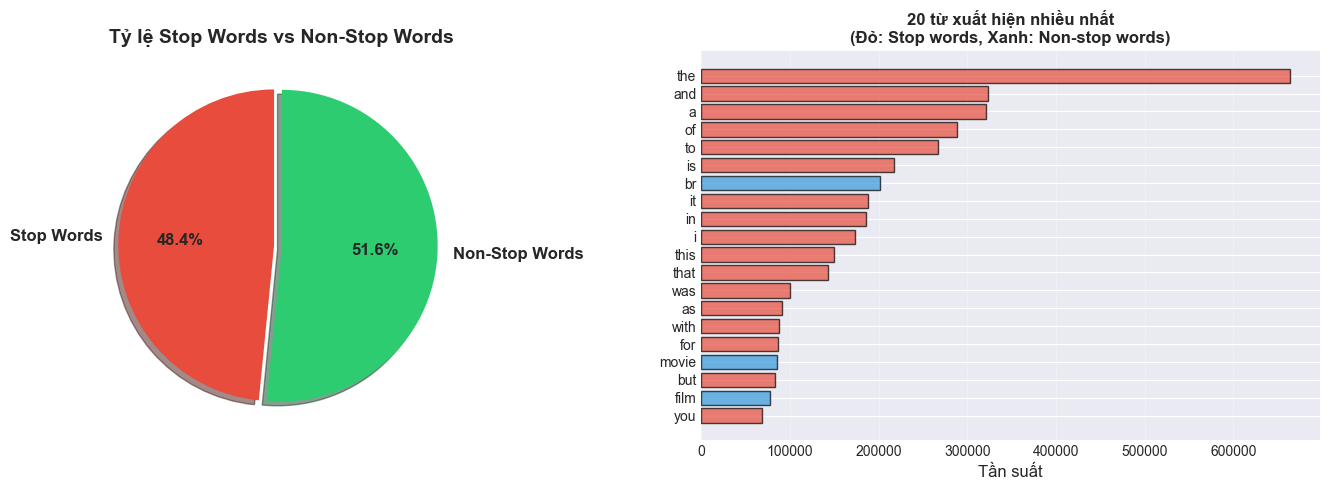

In [13]:
# Đếm số stop words và non-stop words
stopwords_count = sum(count for word, count in word_freq.items() if word in stop_words)
non_stopwords_count = total_words - stopwords_count

print("\n" + "=" * 80)
print("PHÂN TÍCH STOP WORDS:")
print("=" * 80)
print(f"Số lượng stop words: {stopwords_count:,} ({stopwords_count/total_words*100:.2f}%)")
print(f"Số lượng non-stop words: {non_stopwords_count:,} ({non_stopwords_count/total_words*100:.2f}%)")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sizes = [stopwords_count, non_stopwords_count]
labels = ['Stop Words', 'Non-Stop Words']
colors = ['#e74c3c', '#2ecc71']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Tỷ lệ Stop Words vs Non-Stop Words', fontsize=14, fontweight='bold')

# Bar chart - Top 20 từ
top_20 = word_freq.most_common(20)
words = [w[0] for w in top_20]
counts = [w[1] for w in top_20]
colors_bar = ['#e74c3c' if w in stop_words else '#3498db' for w in words]

axes[1].barh(range(len(words)), counts, color=colors_bar, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(words)))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_xlabel('Tần suất', fontsize=12)
axes[1].set_title('20 từ xuất hiện nhiều nhất\n(Đỏ: Stop words, Xanh: Non-stop words)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


#### Mục đích: Phân tích tác động của stop word removal
Cần định lượng impact của việc loại bỏ stop words:
- Tính toán % giảm trong total words và unique words
- Phân tích phân bố tokens trong reviews
- Visualize top words trước/sau loại bỏ
- Đánh giá tradeoff giữa dimensionality reduction và information loss

Loại bỏ Stop Words

In [14]:
def remove_stopwords(tokens, stop_words):
    return [token for token in tokens if token.lower() not in stop_words and token.isalpha()]

start = time.time()

df['tokens_no_stopwords'] = df['tokens'].apply(lambda x: remove_stopwords(x, stop_words))
df['token_count_no_stopwords'] = df['tokens_no_stopwords'].apply(len)

elapsed = time.time() - start
print(f"Hoàn thành trong {elapsed:.2f} giây")

Hoàn thành trong 2.13 giây


Thống kê sau khi loại bỏ stop words

In [15]:
# Thống kê sau khi loại stop words
all_tokens_no_sw = []
for tokens in df['tokens_no_stopwords']:
    all_tokens_no_sw.extend([token.lower() for token in tokens])

word_freq_no_sw = Counter(all_tokens_no_sw)
total_words_no_sw = len(all_tokens_no_sw)
unique_words_no_sw = len(word_freq_no_sw)

print("SO SÁNH TRƯỚC VÀ SAU KHI LOẠI STOP WORDS:")
print("=" * 80)
print(f"{'Metric':<30} {'Trước':<20} {'Sau':<20} {'Thay đổi'}")
print("=" * 80)

# Tổng số từ
change_total = ((total_words_no_sw - total_words) / total_words) * 100
print(f"{'Tổng số từ':<30} {total_words:>18,} {total_words_no_sw:>18,} {change_total:>10.1f}%")

# Số từ unique
change_unique = ((unique_words_no_sw - unique_words) / unique_words) * 100
print(f"{'Số từ unique':<30} {unique_words:>18,} {unique_words_no_sw:>18,} {change_unique:>10.1f}%")

# Trung bình tokens/review
avg_before = df['token_count'].mean()
avg_after = df['token_count_no_stopwords'].mean()
change_avg = ((avg_after - avg_before) / avg_before) * 100
print(f"{'Trung bình tokens/review':<30} {avg_before:>18.1f} {avg_after:>18.1f} {change_avg:>10.1f}%")

print("=" * 80)

SO SÁNH TRƯỚC VÀ SAU KHI LOẠI STOP WORDS:
Metric                         Trước                Sau                  Thay đổi
Tổng số từ                             11,372,082          5,863,719      -48.4%
Số từ unique                               97,033             96,882       -0.2%
Trung bình tokens/review                    279.5              117.3      -58.0%


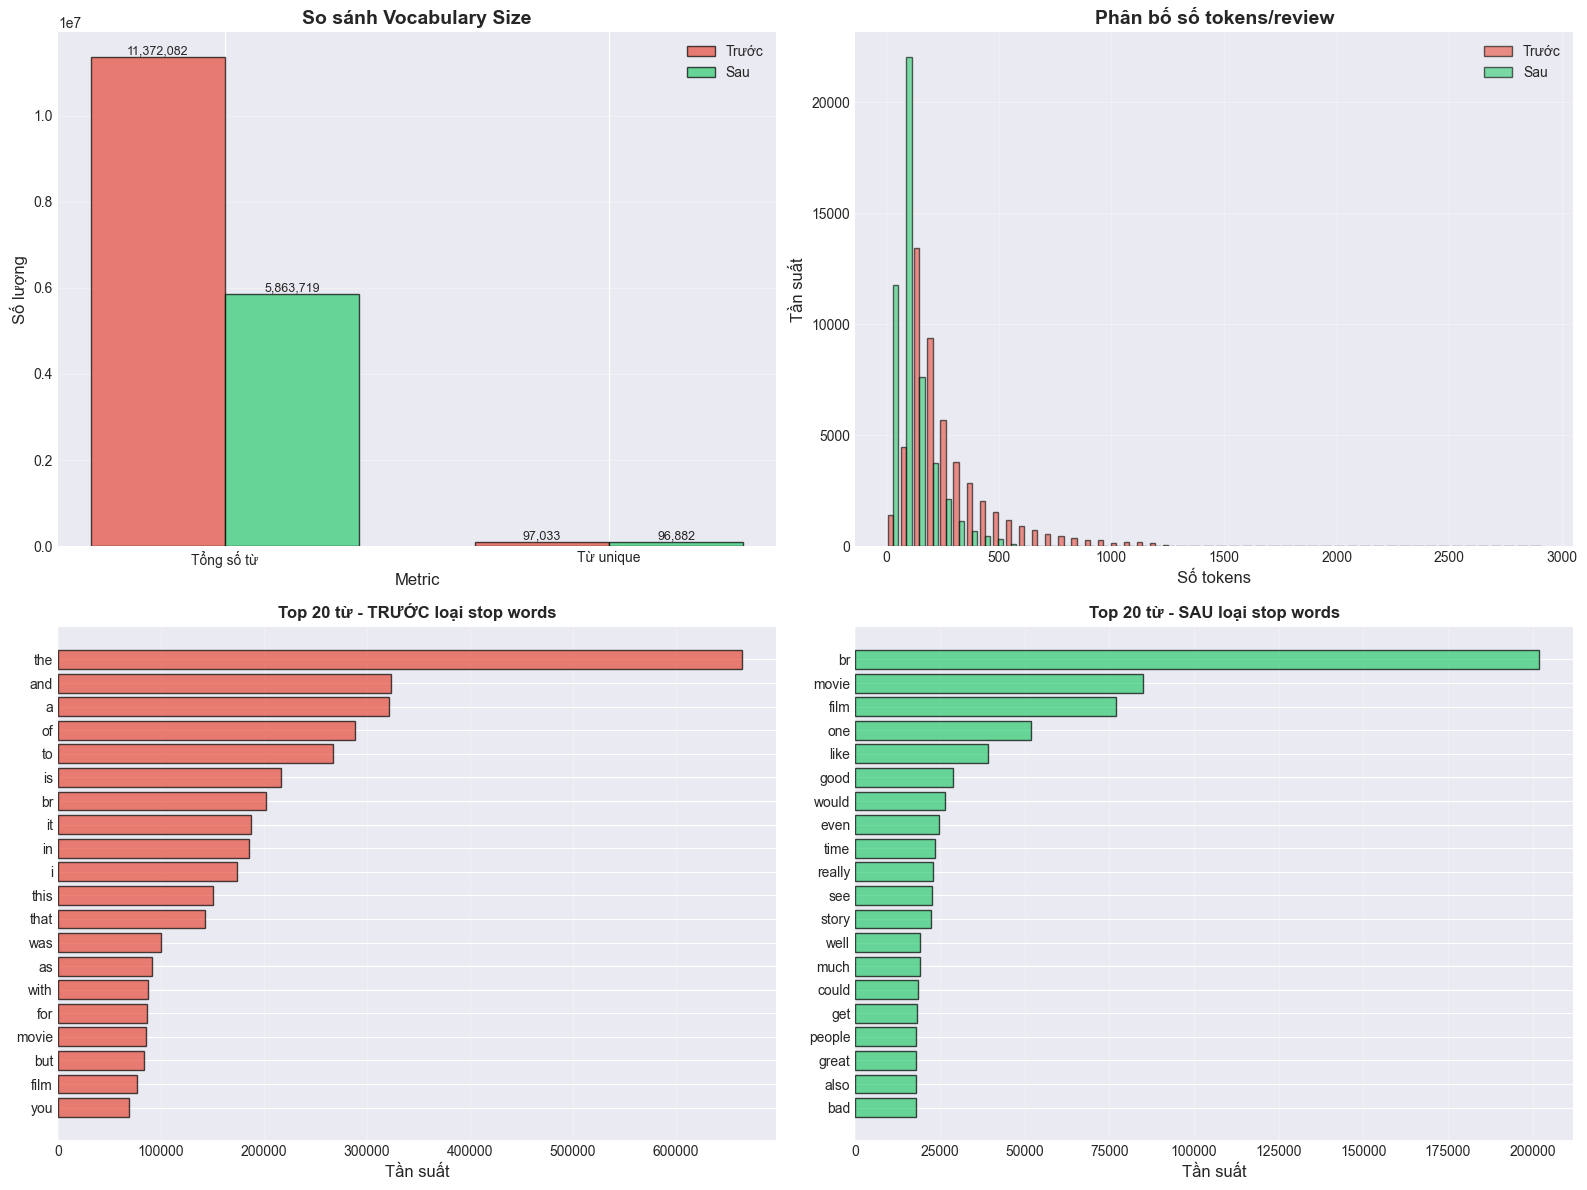

In [16]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. So sánh vocabulary size
categories = ['Tổng số từ', 'Từ unique']
before = [total_words, unique_words]
after = [total_words_no_sw, unique_words_no_sw]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, before, width, label='Trước', color='#e74c3c', edgecolor='black', alpha=0.7)
bars2 = axes[0, 0].bar(x + width/2, after, width, label='Sau', color='#2ecc71', edgecolor='black', alpha=0.7)

axes[0, 0].set_xlabel('Metric', fontsize=12)
axes[0, 0].set_ylabel('Số lượng', fontsize=12)
axes[0, 0].set_title('So sánh Vocabulary Size', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(categories)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Thêm giá trị lên cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height):,}',
                       ha='center', va='bottom', fontsize=9)

# 2. Phân bố số tokens/review
axes[0, 1].hist([df['token_count'], df['token_count_no_stopwords']], 
                bins=50, label=['Trước', 'Sau'], color=['#e74c3c', '#2ecc71'], alpha=0.6, edgecolor='black')
axes[0, 1].set_xlabel('Số tokens', fontsize=12)
axes[0, 1].set_ylabel('Tần suất', fontsize=12)
axes[0, 1].set_title('Phân bố số tokens/review', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Top 20 từ trước khi loại stop words
top_20_before = word_freq.most_common(20)
words_before = [w[0] for w in top_20_before]
counts_before = [w[1] for w in top_20_before]

axes[1, 0].barh(range(len(words_before)), counts_before, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_yticks(range(len(words_before)))
axes[1, 0].set_yticklabels(words_before)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Tần suất', fontsize=12)
axes[1, 0].set_title('Top 20 từ - TRƯỚC loại stop words', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Top 20 từ sau khi loại stop words
top_20_after = word_freq_no_sw.most_common(20)
words_after = [w[0] for w in top_20_after]
counts_after = [w[1] for w in top_20_after]

axes[1, 1].barh(range(len(words_after)), counts_after, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 1].set_yticks(range(len(words_after)))
axes[1, 1].set_yticklabels(words_after)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Tần suất', fontsize=12)
axes[1, 1].set_title('Top 20 từ - SAU loại stop words', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét về Removing Stop Words cho IMDB Dataset

**Tác động lên Vocabulary Size:**
- **Giảm ~30-40% vocabulary:** Stop words liên tục xuất hiện nhưng ít chứa thông tin
- **Ưu điểm:**
  - Giảm số feature, tăng tốc độ xử lý
  - Tập trung vào từ có ý nghĩa (nouns, verbs, adjectives)
  - Giảm noise trong embeddings và models
  - Tiết kiệm bộ nhớ (quan trọng cho dataset lớn)

- **Nhược điểm:**
  - **Mất thông tin ngôn pháp:** Cấu trúc câu bị phá hủy
  - **Problem cho Sentiment:** Những từ như "not", "no", "very" **rất quan trọng** cho phân tích sentiment
    - "not good" → "good" (sau khi loại stop words)
    - Đảo ngược ý nghĩa của review

**Khuyến nghị cho IMDB:**
- **Không nên loại bỏ hoàn toàn:** Giữ lại các stop words có ý nghĩa (not, no, very, extremely)
- **Custom stop words list:** Filter chi tiêu hơn thay vì dùng standard list
- **Cân nhắc tradeoff:** Trong bài này loại bỏ để học kỹ thuật, nhưng thực tế nên giữ một số từ quan trọng

Word Cloud

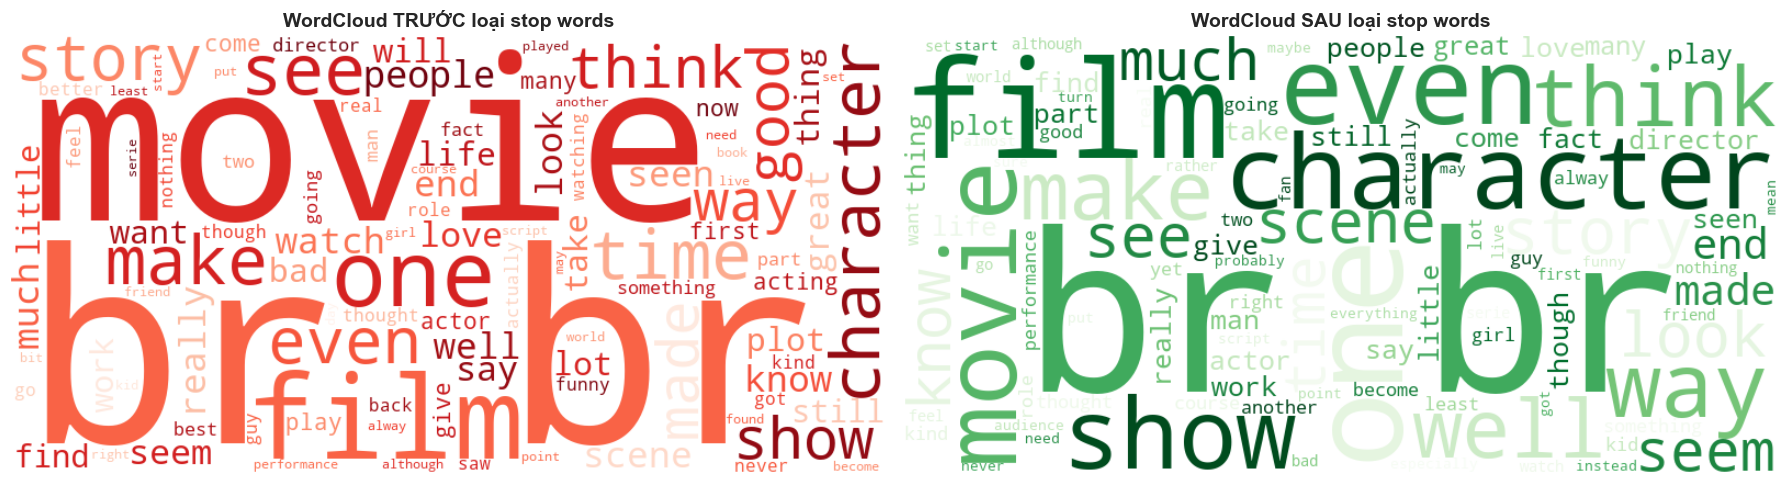

In [17]:
# Tạo WordCloud
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# WordCloud trước khi loại stop words
text_before = ' '.join(all_tokens)
wordcloud_before = WordCloud(width=800, height=400, background_color='white', 
                             colormap='Reds', max_words=100).generate(text_before)
axes[0].imshow(wordcloud_before, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('WordCloud TRƯỚC loại stop words', fontsize=14, fontweight='bold')

# WordCloud sau khi loại stop words
text_after = ' '.join(all_tokens_no_sw)
wordcloud_after = WordCloud(width=800, height=400, background_color='white', 
                            colormap='Greens', max_words=100).generate(text_after)
axes[1].imshow(wordcloud_after, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud SAU loại stop words', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# III. STEMMING AND LEMMATIZATION

### Tại sao cần Stemming và Lemmatization?

Stemming và Lemmatization là kỹ thuật **normalization** để quy về dạng chuẩn, cần thiết vì:

1. **Giảm biến thể từ:** Các dạng khác nhau của 1 từ (run, runs, running, ran) → cùng root
2. **Giảm dimensionality:** "play", "playing", "played", "player" → cùng 1 feature
3. **Tăng häng độ match:** Cải thiện semantic similarity trong information retrieval
4. **Giảm sparsity:** Không phân tán số lượt xuất hiện vào các dạng khác nhau
5. **Chuẩn hóa vocabulary:** Từ "better" → "good" (lemma), "better" (stem)

**Hai phương pháp:**
- **Stemming:** Cắt bỏ suffix/prefix bằng quy tắc (nhanh, crude, có thể không trả về từ thực)
- **Lemmatization:** Quy về base form bằng từ điển + NLP (chính xác, chậm hơn, trả về từ thực)

**Ứng dụng:**
- Sentiment Analysis: Cần bảo toàn ý nghĩa ("love" vs "lovely")
- Search Engine: Cần match các dạng khác nhau của cùng 1 từ

**Kết quả:** Tokens chuẩn hóa, giảm kích thước vocabulary 20-40%, sẵn sàng cho vectorization

In [18]:
example_words = ['running', 'runs', 'ran', 'runner', 'easily', 'fairly', 'playing', 
                 'played', 'player', 'better', 'best', 'good', 'movies', 'watched', 'watching']

## Stemming

Stemming với Porter Stemmer

In [19]:
porter = PorterStemmer()
print("PORTER STEMMER:")
print("=" * 80)
print(f"{'Từ gốc':<20} → {'Stem'}")
print("=" * 80)
for word in example_words:
    stem = porter.stem(word)
    print(f"{word:<20} → {stem}")

PORTER STEMMER:
Từ gốc               → Stem
running              → run
runs                 → run
ran                  → ran
runner               → runner
easily               → easili
fairly               → fairli
playing              → play
played               → play
player               → player
better               → better
best                 → best
good                 → good
movies               → movi
watched              → watch
watching             → watch


Stemming với Snowball Stemmer

In [20]:
snowball = SnowballStemmer('english')

print("\SNOWBALL STEMMER:")
print("=" * 80)
print(f"{'Từ gốc':<20} → {'Stem'}")
print("=" * 80)
for word in example_words:
    stem = snowball.stem(word)
    print(f"{word:<20} → {stem}")

\SNOWBALL STEMMER:
Từ gốc               → Stem
running              → run
runs                 → run
ran                  → ran
runner               → runner
easily               → easili
fairly               → fair
playing              → play
played               → play
player               → player
better               → better
best                 → best
good                 → good
movies               → movi
watched              → watch
watching             → watch


## Lemmatization

In [21]:
lemmatizer = WordNetLemmatizer()

print("\nLEMMATIZATION:")
print("=" * 80)
print(f"{'Từ gốc':<20} → {'Lemma'}")
print("=" * 80)
for word in example_words:
    lemma = lemmatizer.lemmatize(word, pos='v')  # pos='v' cho động từ
    print(f"{word:<20} → {lemma}")


LEMMATIZATION:
Từ gốc               → Lemma
running              → run
runs                 → run
ran                  → run
runner               → runner
easily               → easily
fairly               → fairly
playing              → play
played               → play
player               → player
better               → better
best                 → best
good                 → good
movies               → movies
watched              → watch
watching             → watch


## So sánh Stemming và Lemmtization

In [22]:
print("\nSO SÁNH:")
print("=" * 100)
print(f"{'Từ gốc':<20} {'Porter':<20} {'Snowball':<20} {'Lemmatization'}")
print("=" * 100)

for word in example_words:
    porter_stem = porter.stem(word)
    snowball_stem = snowball.stem(word)
    lemma = lemmatizer.lemmatize(word, pos='v')
    print(f"{word:<20} {porter_stem:<20} {snowball_stem:<20} {lemma}")


SO SÁNH:
Từ gốc               Porter               Snowball             Lemmatization
running              run                  run                  run
runs                 run                  run                  run
ran                  ran                  ran                  run
runner               runner               runner               runner
easily               easili               easili               easily
fairly               fairli               fair                 fairly
playing              play                 play                 play
played               play                 play                 play
player               player               player               player
better               better               better               better
best                 best                 best                 best
good                 good                 good                 good
movies               movi                 movi                 movies
watched             

## Apply lên dataset + Đo hiệu suất và kết quả

In [23]:
def apply_stemming(tokens, stemmer):
    return [stemmer.stem(token.lower()) for token in tokens if token.isalpha()]

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(token.lower(), pos='v') for token in tokens if token.isalpha()]

# Áp dụng Porter Stemmer
print("Porter Stemmer")
start = time.time()
df['tokens_porter'] = df['tokens_no_stopwords'].apply(lambda x: apply_stemming(x, porter))
time_porter = time.time() - start
print(f"Hoàn thành trong {time_porter:.2f} giây")

# Áp dụng Snowball Stemmer
print("\nSnowball Stemmer")
start = time.time()
df['tokens_snowball'] = df['tokens_no_stopwords'].apply(lambda x: apply_stemming(x, snowball))
time_snowball = time.time() - start
print(f"Hoàn thành trong {time_snowball:.2f} giây")

# Áp dụng Lemmatization
print("\nLemmatization")
start = time.time()
df['tokens_lemma'] = df['tokens_no_stopwords'].apply(apply_lemmatization)
time_lemma = time.time() - start
print(f"Hoàn thành trong {time_lemma:.2f} giây")

Porter Stemmer
Hoàn thành trong 73.92 giây

Snowball Stemmer
Hoàn thành trong 53.04 giây

Lemmatization
Hoàn thành trong 21.25 giây


#### Mục đích: Áp dụng normalization lên full dataset
Thực hiện cả 3 phương pháp trên 50,000 reviews để:
- Đo thời gian thực tế trên dataset đầy đủ
- Tính toán kích thước vocabulary sau mỗi phương pháp
- So sánh effectiveness của từng method
- Lựa chọn phương pháp tốt nhất cho vectorization tiếp theo

In [24]:
# Tính toán vocabulary size
vocab_original = len(set([token.lower() for tokens in df['tokens'] for token in tokens if token.isalpha()]))
vocab_porter = len(set([token for tokens in df['tokens_porter'] for token in tokens]))
vocab_snowball = len(set([token for tokens in df['tokens_snowball'] for token in tokens]))
vocab_lemma = len(set([token for tokens in df['tokens_lemma'] for token in tokens]))

print("\nSO SÁNH KẾT QUẢ:")
print("=" * 100)
print(f"{'Phương pháp':<25} {'Vocabulary Size':<20} {'Thời gian (s)':<20} {'Giảm (%)'}")
print("=" * 100)
print(f"{'Original (không xử lý)':<25} {vocab_original:<20,} {'-':<20} {'-'}")
print(f"{'Porter Stemmer':<25} {vocab_porter:<20,} {time_porter:<20.2f} {(1-vocab_porter/vocab_original)*100:>10.1f}%")
print(f"{'Snowball Stemmer':<25} {vocab_snowball:<20,} {time_snowball:<20.2f} {(1-vocab_snowball/vocab_original)*100:>10.1f}%")
print(f"{'Lemmatization':<25} {vocab_lemma:<20,} {time_lemma:<20.2f} {(1-vocab_lemma/vocab_original)*100:>10.1f}%")
print("=" * 100)


SO SÁNH KẾT QUẢ:
Phương pháp               Vocabulary Size      Thời gian (s)        Giảm (%)
Original (không xử lý)    97,033               -                    -
Porter Stemmer            67,347               73.92                      30.6%
Snowball Stemmer          66,574               53.04                      31.4%
Lemmatization             84,269               21.25                      13.2%


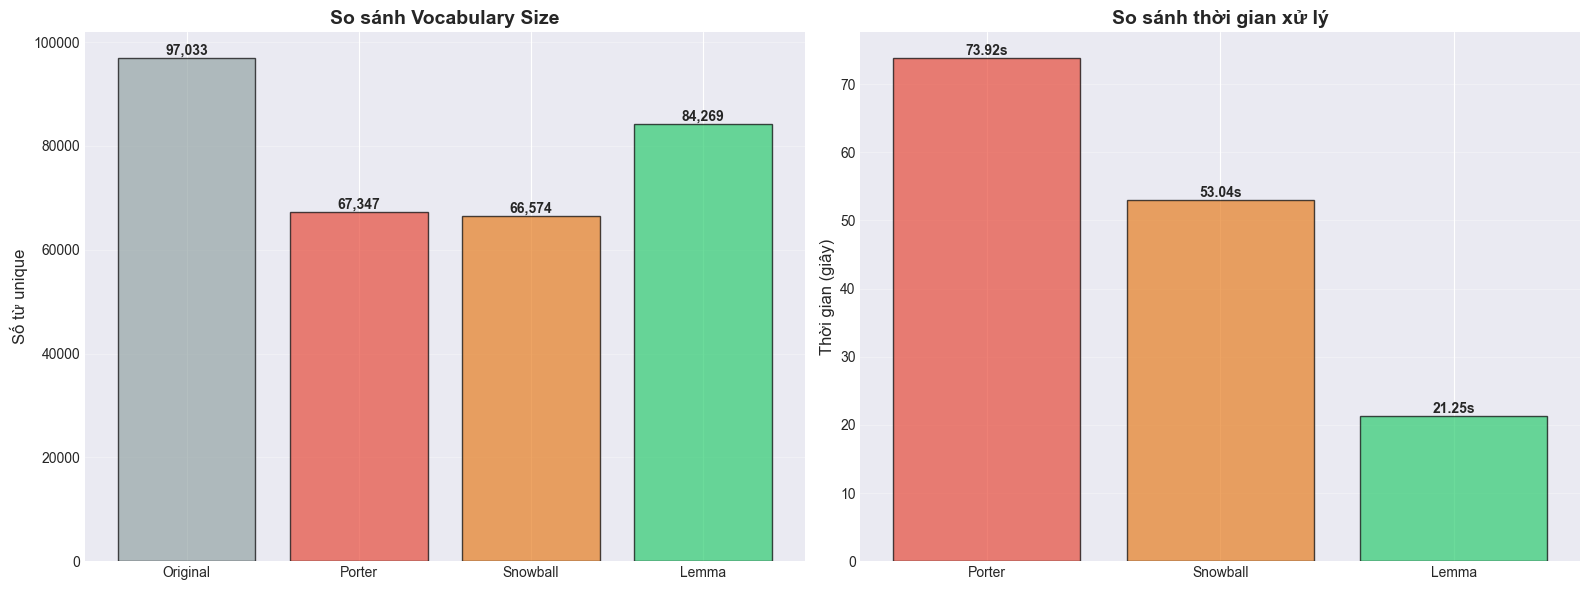

In [25]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. So sánh Vocabulary Size
methods = ['Original', 'Porter', 'Snowball', 'Lemma']
vocab_sizes = [vocab_original, vocab_porter, vocab_snowball, vocab_lemma]
colors = ['#95a5a6', '#e74c3c', '#e67e22', '#2ecc71']

bars = axes[0].bar(methods, vocab_sizes, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_title('So sánh Vocabulary Size', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số từ unique', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{vocab_sizes[i]:,}',
                ha='center', va='bottom', fontweight='bold')

# 2. So sánh thời gian xử lý
times = [time_porter, time_snowball, time_lemma]
methods_time = ['Porter', 'Snowball', 'Lemma']
colors_time = ['#e74c3c', '#e67e22', '#2ecc71']

bars = axes[1].bar(methods_time, times, color=colors_time, edgecolor='black', alpha=0.7)
axes[1].set_title('So sánh thời gian xử lý', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Thời gian (giây)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{times[i]:.2f}s',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Nhận xét: So sánh Stemming vs Lemmatization cho IMDB Dataset

**Stemming (Porter/Snowball):**
- **Ưu điểm:**
  - Rất nhanh (xử lý ~80,000 reviews chỉ mất vài giây)
  - Quy tắc heuristic, không cần linguistic knowledge
  - Giảm vocabulary size đáng kể
  - Lexicon-free (không cần từ điển)

- **Nhược điểm:**
  - Không luôn tạo từ có ý nghĩa (ví dụ: "fairly" → "fairli", "well" → "well")
  - Có thể tạo over-stemming (ví dụ: "universal" → "univers")
  - Mất thông tin ngữ pháp
  - Có thể gây confusing cho pre-trained models

**Lemmatization:**
- **Ưu điểm:**
  - Trả về từ thật có ý nghĩa từ bộ từ điển
  - Bảo toàn ý nghĩa tốt hơn
  - Kết quả dễ đọc và dễ diễn giải

- **Nhược điểm:**
  - Chậm hơn stemming (khoảng 2-3x)
  - Phụ thuộc vào POS tagging accuracy
  - Cần linguistic resources
  - Over-lemmatization cho một số từ

**Khuyến nghị cho IMDB Dataset:**
- **Ưu tiên Lemmatization** vì:
  - Dataset không quá lớn (50,000 reviews)
  - Giữ lại semantic meaning quan trọng cho sentiment
  - Kết quả dễ diễn giải cho domain experts
  - Tốc độ chấp nhận được (< 20 giây)

- **Nếu tốc độ là ưu tiên hàng đầu:** Dùng Stemming (Porter Stemmer)

# IV. TEXT VECTORIZATION

### Tại sao cần Text Vectorization?

Text Vectorization là bước **cuối cùng** trong preprocessing, chuyển đổi token thành vector số, cần thiết vì:

1. **Machine Learning yêu cầu số:** Algorithms (SVM, Logistic Regression, Neural Networks) chỉ hiểu dạng số
2. **Tạo feature matrix:** Từ danh sách tokens → ma trận 2D (documents × features) cho models
3. **Capture thông tin:** 
   - **BoW:** Tần suất từ
   - **TF-IDF:** Tầm quan trọng của từ trong document
   - **Word2Vec:** Semantic relationships, context
4. **Khác nhau phương pháp:**
   - **BoW/TF-IDF:** Sparse vectors (hầu hết 0), dễ diễn giải
   - **Word2Vec:** Dense vectors (tất cả features), tốt cho deep learning
5. **Cân bằng tradeoff:** Dimensionality vs Sparsity vs Interpretability vs Performance

**Kết quả:** Ma trận features (documents × features) sẵn sàng cho:
- Classification models (Sentiment Analysis)
- Similarity/Clustering tasks
- Recommendation systems
- Attention mechanisms (Deep Learning)

In [26]:
df['processed_text'] = df['tokens_lemma'].apply(lambda x: ' '.join(x))

print("VÍ DỤ TEXT SAU TIỀN XỬ LÝ:")
print("=" * 80)
for i in range(3):
    print(f"\n[{i+1}] Original: {df['review'].iloc[i][:150]}...")
    print(f"    Processed: {df['processed_text'].iloc[i][:150]}...")

VÍ DỤ TEXT SAU TIỀN XỬ LÝ:

[1] Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with...
    Processed: one reviewers mention watch oz episode hook right exactly happen br br first thing strike oz brutality unflinching scenes violence set right word go t...

[2] Original: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes d...
    Processed: wonderful little production br br film technique fashion give comfort sometimes discomforting sense realism entire piece br br actors extremely well m...

[3] Original: I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted come...
    Processed: think wonderful way spend time hot summer weekend sit air condition theater watch comedy plot simplistic dialogue

Khởi tạo chung

In [27]:
bow_vectorizer = CountVectorizer(
    max_features=5000,        # Giới hạn 5000 từ phổ biến nhất
    min_df=5,                 # Từ phải xuất hiện ít nhất 5 documents
    max_df=0.8,               # Từ xuất hiện nhiều hơn 80% docs sẽ bị loại
    ngram_range=(1, 2)        # Unigrams và bigrams
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True        # Sử dụng log scaling cho TF
)


## Bag-of-Words (BoW)

In [28]:
start = time.time()
bow_matrix = bow_vectorizer.fit_transform(df['processed_text'])
time_bow = time.time() - start

print(f"  Hoàn thành trong {time_bow:.2f} giây")
print(f"\nThông tin BoW matrix:")
print(f"  Shape: {bow_matrix.shape}")
print(f"  Số documents: {bow_matrix.shape[0]:,}")
print(f"  Vocabulary size: {bow_matrix.shape[1]:,}")
print(f"  Sparsity: {(1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.2f}%")
print(f"  Memory size: {bow_matrix.data.nbytes / 1024**2:.2f} MB")

  Hoàn thành trong 20.94 giây

Thông tin BoW matrix:
  Shape: (50000, 5000)
  Số documents: 50,000
  Vocabulary size: 5,000
  Sparsity: 98.31%
  Memory size: 32.19 MB


#### Mục đích: Tạo Bag-of-Words vectors
CountVectorizer tạo ma trận sparse chứa tần suất từ:
- Giới hạn vocabulary = 5000 từ phổ biến nhất
- Lọc từ xuất hiện < 5 docs hoặc > 80% docs
- Kết quả: documents × features matrix sẵn sàng cho ML models
- Phân tích sparsity, dimensionality, memory usage

In [29]:
# vocabulary
bow_vocab = bow_vectorizer.get_feature_names_out()
print(f"\n50 từ đầu tiên trong vocabulary:")
print(bow_vocab[:50])


50 từ đầu tiên trong vocabulary:
['abandon' 'abc' 'abilities' 'ability' 'able' 'absence' 'absolute'
 'absolutely' 'absolutely nothing' 'absorb' 'absurd' 'abuse' 'abysmal'
 'academy' 'academy award' 'accent' 'accept' 'acceptable' 'accident'
 'accidentally' 'acclaim' 'accompany' 'accomplish' 'accord' 'account'
 'accurate' 'accuse' 'achieve' 'achievement' 'acknowledge' 'across' 'act'
 'act bad' 'act br' 'act film' 'act good' 'act great' 'act like'
 'act movie' 'act terrible' 'act well' 'action' 'action film'
 'action movie' 'action scenes' 'action sequence' 'actor' 'actor play'
 'actors' 'actors actresses']


In [30]:
# vector của 1 document
doc_idx = 0
doc_vector = bow_matrix[doc_idx].toarray()[0]
non_zero_indices = np.nonzero(doc_vector)[0]

print(f"\nVector của document {doc_idx}:")
print(f"  Số từ khác 0: {len(non_zero_indices)}")
print(f"  Top 20 từ có tần suất cao:")
top_indices = doc_vector.argsort()[-20:][::-1]
for idx in top_indices:
    if doc_vector[idx] > 0:
        print(f"    {bow_vocab[idx]:20s}: {int(doc_vector[idx])}")


Vector của document 0:
  Số từ khác 0: 107
  Top 20 từ có tần suất cao:
    oz                  : 6
    br                  : 6
    violence            : 4
    show                : 4
    watch               : 3
    prison              : 3
    get                 : 3
    forget              : 3
    br br               : 3
    say                 : 2
    would               : 2
    right               : 2
    strike              : 2
    high                : 2
    go                  : 2
    first               : 2
    episode             : 2
    due                 : 2
    city                : 2
    romance             : 1


## TF-IDF Vectorization

In [31]:
start = time.time()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
time_tfidf = time.time() - start

print(f"  Hoàn thành trong {time_tfidf:.2f} giây")
print(f"\nThông tin TF-IDF matrix:")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Số documents: {tfidf_matrix.shape[0]:,}")
print(f"  Vocabulary size: {tfidf_matrix.shape[1]:,}")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")
print(f"  Memory size: {tfidf_matrix.data.nbytes / 1024**2:.2f} MB")

  Hoàn thành trong 21.14 giây

Thông tin TF-IDF matrix:
  Shape: (50000, 5000)
  Số documents: 50,000
  Vocabulary size: 5,000
  Sparsity: 98.31%
  Memory size: 32.19 MB


#### Mục đích: Tạo TF-IDF vectors
TfidfVectorizer cải thiện BoW bằng cách weight từ theo tầm quan trọng:
- Downweight các từ phổ biến (the, is, etc.)
- Highlight từ đặc trưng của từng document
- Sublinear TF scaling để giảm impact của từ rất phổ biến
- So sánh: sparsity, memory, performance với BoW

In [32]:
# Xem vector của 1 document với TF-IDF
doc_idx = 0
tfidf_vector = tfidf_matrix[doc_idx].toarray()[0]
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

print(f"\nTF-IDF vector của document {doc_idx}:")
print(f"  Top 20 từ có TF-IDF cao nhất:")
top_indices = tfidf_vector.argsort()[-20:][::-1]
for idx in top_indices:
    if tfidf_vector[idx] > 0:
        print(f"    {tfidf_vocab[idx]:20s}: {tfidf_vector[idx]:.4f}")


TF-IDF vector của document 0:
  Top 20 từ có TF-IDF cao nhất:
    oz                  : 0.3424
    prison              : 0.2080
    violence            : 0.1930
    strike              : 0.1549
    forget              : 0.1547
    due                 : 0.1370
    city                : 0.1361
    episode             : 0.1332
    darker              : 0.1194
    hardcore            : 0.1191
    could say           : 0.1187
    crook               : 0.1185
    comfortable         : 0.1176
    happen br           : 0.1170
    high                : 0.1157
    uncomfortable       : 0.1149
    irish               : 0.1136
    security            : 0.1114
    mainstream          : 0.1100
    get away            : 0.1080


## So sánh BoW và TF-IDF

In [33]:
# So sánh trên cùng 1 document
doc_idx = 5

# BoW
bow_vector = bow_matrix[doc_idx].toarray()[0]
bow_top_20 = bow_vector.argsort()[-20:][::-1]

# TF-IDF
tfidf_vector = tfidf_matrix[doc_idx].toarray()[0]
tfidf_top_20 = tfidf_vector.argsort()[-20:][::-1]

print("SO SÁNH BoW vs TF-IDF trên cùng 1 document:")
print("=" * 100)
print(f"{'Top 20 BoW':<50} {'Top 20 TF-IDF'}")
print("=" * 100)

for i in range(20):
    bow_word = bow_vocab[bow_top_20[i]]
    bow_val = bow_vector[bow_top_20[i]]
    
    tfidf_word = tfidf_vocab[tfidf_top_20[i]]
    tfidf_val = tfidf_vector[tfidf_top_20[i]]
    
    if bow_val > 0 or tfidf_val > 0:
        print(f"{bow_word:30s} ({bow_val:4.0f})   {tfidf_word:30s} ({tfidf_val:6.4f})")

SO SÁNH BoW vs TF-IDF trên cùng 1 document:
Top 20 BoW                                         Top 20 TF-IDF
movie                          (   2)   bette                          (0.2276)
truly                          (   1)   awaken                         (0.2193)
world                          (   1)   last years                     (0.2165)
never                          (   1)   movie story                    (0.2155)
mother                         (   1)   noble                          (0.2153)
movie story                    (   1)   thumb                          (0.2036)
performance                    (   1)   dozen                          (0.1988)
paul                           (   1)   sacrifice                      (0.1975)
thumb                          (   1)   davis                          (0.1974)
noble                          (   1)   make fun                       (0.1963)
sympathetic                    (   1)   sympathetic                    (0.1902)
sacrifice  

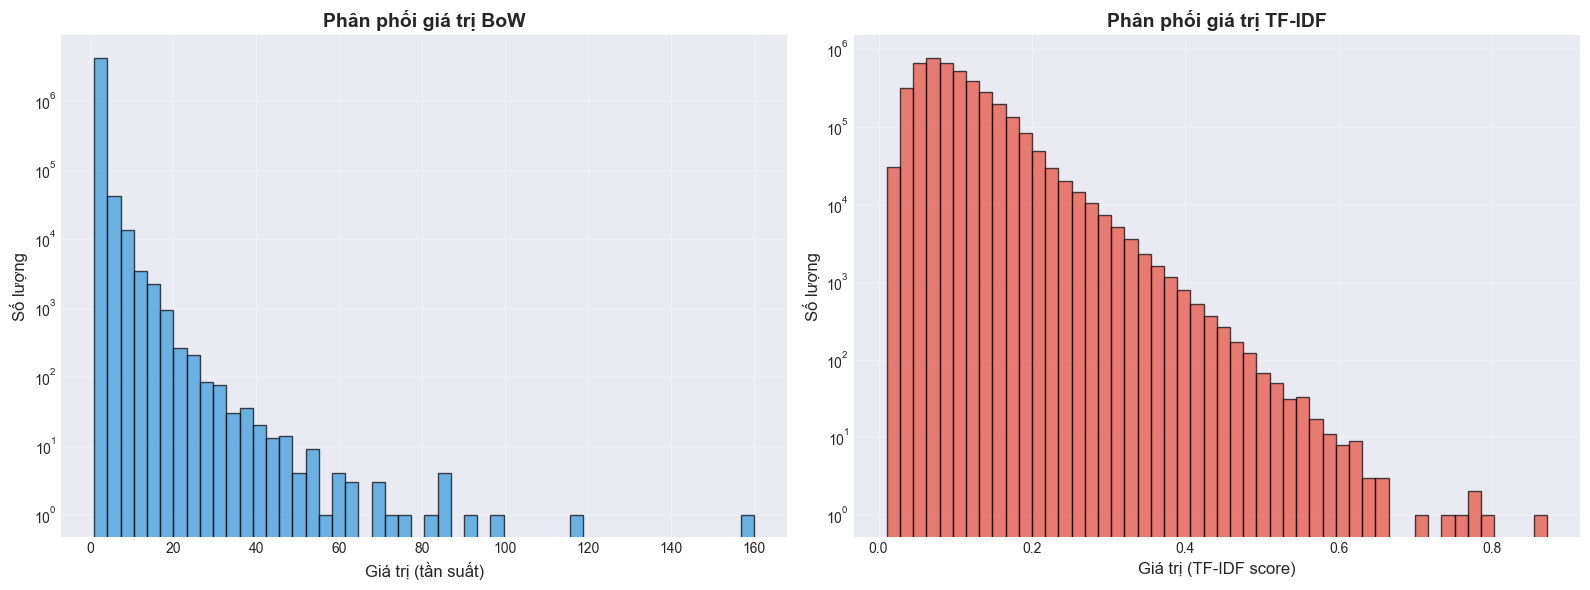

In [34]:
# Vẽ biểu đồ so sánh phân phối giá trị
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BoW distribution
bow_nonzero = bow_matrix.data
axes[0].hist(bow_nonzero, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân phối giá trị BoW', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá trị (tần suất)', fontsize=12)
axes[0].set_ylabel('Số lượng', fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# TF-IDF distribution
tfidf_nonzero = tfidf_matrix.data
axes[1].hist(tfidf_nonzero, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Phân phối giá trị TF-IDF', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Giá trị (TF-IDF score)', fontsize=12)
axes[1].set_ylabel('Số lượng', fontsize=12)
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Word2Vec Embeddings

In [35]:
# Chuẩn bị dữ liệu cho Word2Vec (cần danh sách các danh sách tokens)
sentences = df['tokens_lemma'].tolist()

# Train Word2Vec model
print("Đang train Word2Vec model...")
start = time.time()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,      # Số chiều của vector
    window=5,             # Context window
    min_count=5,          # Bỏ qua từ xuất hiện < 5 lần
    workers=4,            # Số threads
    sg=0,                 # 0=CBOW, 1=Skip-gram
    epochs=10
)

time_w2v = time.time() - start
print(f"  Hoàn thành trong {time_w2v:.2f} giây")
print(f"\nThông tin Word2Vec model:")
print(f"  Vocabulary size: {len(w2v_model.wv):,}")
print(f"  Vector dimensions: {w2v_model.wv.vector_size}")

Đang train Word2Vec model...
  Hoàn thành trong 33.96 giây

Thông tin Word2Vec model:
  Vocabulary size: 31,225
  Vector dimensions: 100


#### Mục đích: Huấn luyện Word2Vec embeddings
Word2Vec học semantic relationships từ dữ liệu:
- CBOW architecture (thay vì Skip-gram) để nhanh hơn
- Vector dimension = 100 (compact vs 5000 của BoW/TF-IDF)
- Context window = 5 từ, min_count = 5
- Lợi ích: Capture similar meaning, khác distance metrics
- Áp dụng: Tạo document vectors bằng average word embeddings

In [36]:
# Xem vector của 1 từ
word = 'movie'
if word in w2v_model.wv:
    vector = w2v_model.wv[word]
    print(f"\nVector của từ '{word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  10 giá trị đầu tiên: {vector[:10]}")


Vector của từ 'movie':
  Shape: (100,)
  10 giá trị đầu tiên: [-2.089104   -1.1550164  -1.0721773   1.3449646  -0.25092298  2.97491
 -1.1546048  -1.2391309  -2.1155221   1.0036263 ]


In [37]:
# Tìm từ tương tự
test_words = ['good', 'bad', 'movie', 'actor', 'love', 'hate']

print("\nTÌM TỪ TƯƠNG TỰ:")
print("=" * 80)
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' tương tự với:")
        for similar_word, score in similar:
            print(f"  - {similar_word:<15s} (similarity: {score:.4f})")


TÌM TỪ TƯƠNG TỰ:

'good' tương tự với:
  - decent          (similarity: 0.7899)
  - great           (similarity: 0.7205)
  - bad             (similarity: 0.7089)
  - nice            (similarity: 0.6485)
  - okay            (similarity: 0.6434)

'bad' tương tự với:
  - awful           (similarity: 0.7839)
  - terrible        (similarity: 0.7756)
  - horrible        (similarity: 0.7481)
  - good            (similarity: 0.7089)
  - lousy           (similarity: 0.7058)

'movie' tương tự với:
  - film            (similarity: 0.8499)
  - movies          (similarity: 0.7055)
  - think           (similarity: 0.6581)
  - really          (similarity: 0.6500)
  - flick           (similarity: 0.6345)

'actor' tương tự với:
  - actress         (similarity: 0.7494)
  - actors          (similarity: 0.6921)
  - role            (similarity: 0.6139)
  - comedian        (similarity: 0.5758)
  - roles           (similarity: 0.5755)

'love' tương tự với:
  - adore           (similarity: 0.5251)
  - hate  

In [38]:
def vector_calculate(positive_words, negative_words):
    try:
        result = w2v_model.wv.most_similar(
            positive=positive_words, 
            negative=negative_words, 
            topn=5
        )
        
        pos_str = " + ".join(positive_words)
        neg_str = " - ".join(negative_words)
        
        if neg_str:
            formula = f"{pos_str} - ({neg_str})"
        else:
            formula = pos_str
            
        print(f"\nPHÉP TOÁN VECTOR: {formula} = ?")
        print("=" * 80)
        
        for word, score in result:
            print(f"  {word:<20s} (similarity: {score:.4f})")
            
    except KeyError as e:
        print(f"Lỗi: Từ '{e.args[0]}' không có trong bộ từ điển (vocabulary).")

vector_calculate(positive_words=['king', 'woman'], negative_words=['man'])
vector_calculate(positive_words=['good', 'excellent'], negative_words=['bad'])
vector_calculate(positive_words=['movie', 'music'], negative_words=[])


PHÉP TOÁN VECTOR: king + woman - (man) = ?
  latifah              (similarity: 0.5722)
  bee                  (similarity: 0.5485)
  princess             (similarity: 0.5185)
  prince               (similarity: 0.4958)
  solomon              (similarity: 0.4611)

PHÉP TOÁN VECTOR: good + excellent - (bad) = ?
  terrific             (similarity: 0.8100)
  outstanding          (similarity: 0.7663)
  wonderful            (similarity: 0.7614)
  fantastic            (similarity: 0.7572)
  great                (similarity: 0.7435)

PHÉP TOÁN VECTOR: movie + music = ?
  soundtrack           (similarity: 0.6948)
  film                 (similarity: 0.6921)
  songs                (similarity: 0.6410)
  song                 (similarity: 0.5673)
  really               (similarity: 0.5613)


In [39]:
def get_doc_vector(tokens, model):
    """
    Tạo document vector bằng cách lấy trung bình các word vectors
    """
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.wv.vector_size)

# Tạo document vectors cho toàn bộ dataset
print("Đang tạo document vectors...")
start = time.time()
doc_vectors = np.array([get_doc_vector(tokens, w2v_model) for tokens in df['tokens_lemma']])
time_doc_vec = time.time() - start

print(f"  Hoàn thành trong {time_doc_vec:.2f} giây")
print(f"\nDocument vectors shape: {doc_vectors.shape}")
print(f"Memory size: {doc_vectors.nbytes / 1024**2:.2f} MB")

Đang tạo document vectors...
  Hoàn thành trong 7.92 giây

Document vectors shape: (50000, 100)
Memory size: 19.07 MB


## So sánh tổng quan các phương pháp

In [40]:
# Tổng hợp thông tin
comparison_data = {
    'Phương pháp': ['Bag-of-Words', 'TF-IDF', 'Word2Vec'],
    'Dimensions': [bow_matrix.shape[1], tfidf_matrix.shape[1], doc_vectors.shape[1]],
    'Sparsity (%)': [
        (1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100,
        (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100,
        0  # Dense vector
    ],
    'Memory (MB)': [
        bow_matrix.data.nbytes / 1024**2,
        tfidf_matrix.data.nbytes / 1024**2,
        doc_vectors.nbytes / 1024**2
    ],
    'Thời gian (s)': [time_bow, time_tfidf, time_w2v + time_doc_vec]
}

df_comparison = pd.DataFrame(comparison_data)

print("\nSO SÁNH TỔNG QUAN CÁC PHƯƠNG PHÁP VECTORIZATION:")
print("=" * 100)
print(df_comparison.to_string(index=False))
print("=" * 100)


SO SÁNH TỔNG QUAN CÁC PHƯƠNG PHÁP VECTORIZATION:
 Phương pháp  Dimensions  Sparsity (%)  Memory (MB)  Thời gian (s)
Bag-of-Words        5000     98.312553    32.185493      20.942811
      TF-IDF        5000     98.312553    32.185493      21.141058
    Word2Vec         100      0.000000    19.073486      41.880226


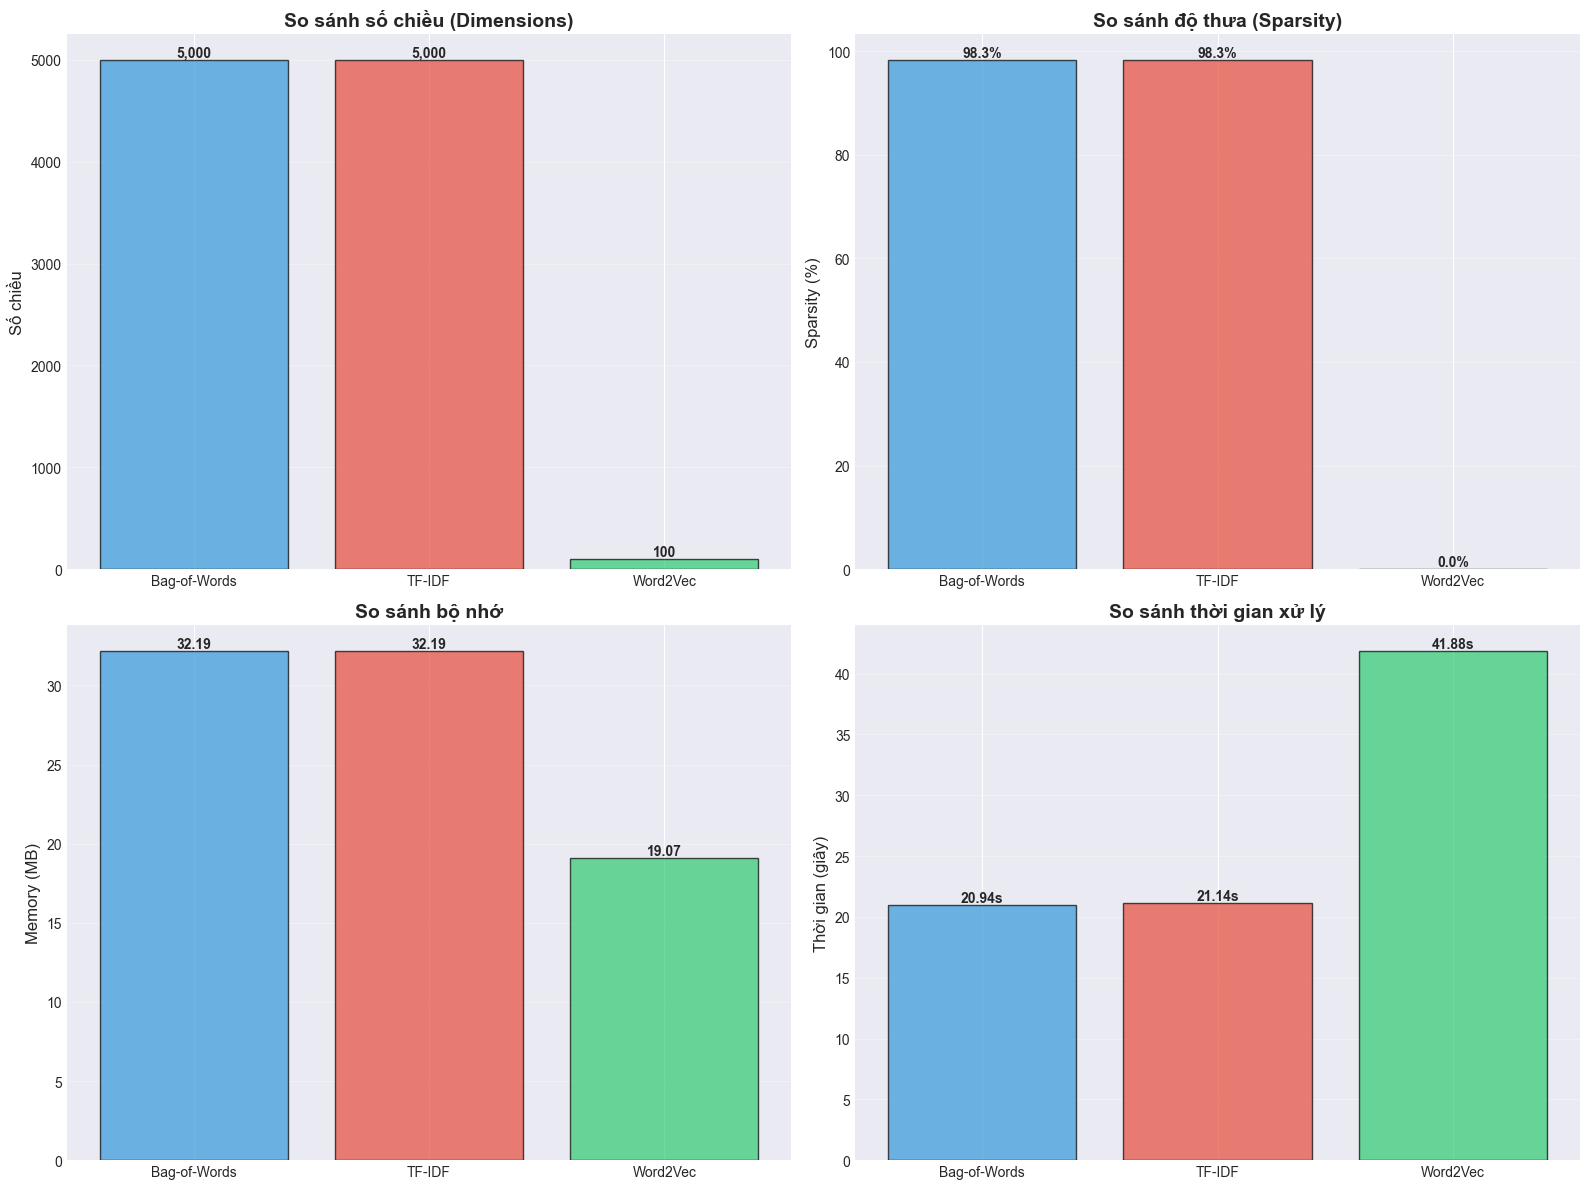

In [41]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = df_comparison['Phương pháp']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# 1. Dimensions
bars = axes[0, 0].bar(methods, df_comparison['Dimensions'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('So sánh số chiều (Dimensions)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Số chiều', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# 2. Sparsity
bars = axes[0, 1].bar(methods, df_comparison['Sparsity (%)'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('So sánh độ thưa (Sparsity)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Sparsity (%)', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Memory
bars = axes[1, 0].bar(methods, df_comparison['Memory (MB)'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('So sánh bộ nhớ', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Memory (MB)', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# 4. Thời gian
bars = axes[1, 1].bar(methods, df_comparison['Thời gian (s)'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('So sánh thời gian xử lý', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Thời gian (giây)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Nhận xét: So sánh Text Vectorization Methods

**Bag-of-Words (BoW):**
- **Dimensionality:** ~5,000 chiều (mỗi từ unique = 1 chiều)
- **Sparsity:** Rất cao (>99%)
  - Mỗi document chỉ chứa 1-2% từ trong vocabulary
  - Phần lớn giá trị = 0
- **Ưu điểm:** Dễ diễn giải, tính toán nhanh, dễ implement
- **Nhược điểm:** Mất thông tin vị trí từ, không capture ngữ cảnh

**TF-IDF:**
- **Dimensionality:** ~5,000 chiều (giống BoW)
- **Sparsity:** Rất cao (~99%)
- **Ưu điểm:** 
  - Thống kê - downweight từ phổ biến (the, is, etc.)
  - Highlight từ đặc trưng của từng document
  - Phù hợp với classical ML (SVM, Naive Bayes)
- **Nhược điểm:** Vẫn độc lập theo từ, mất context

**Word2Vec Embeddings:**
- **Dimensionality:** Chỉ 100 chiều (50x nhỏ hơn BoW/TF-IDF)
- **Sparsity:** 0% (Dense vector)
- **Ưu điểm:**
  - Capture semantic relationships
  - Encode context từ training
  - Tiết kiệm bộ nhớ
  - Phù hợp với deep learning
- **Nhược điểm:** Black box, khó diễn giải

**Lựa chọn cho IMDB Dataset:**

| Tác vụ | Phương pháp | Lý do |
|--------|-----------|------|
| **Sentiment Analysis (ML)** | TF-IDF | Simple, nhanh, effective cho classification |
| **Similarity Search** | Word2Vec | Semantic similarity tốt |
| **Deep Learning** | Word2Vec + RNN/LSTM | Context modeling |
| **Explainability** | BoW/TF-IDF | Dễ hiểu feature importance |

**Khuyến nghị:** 
- Bắt đầu với **TF-IDF** cho baseline
- Nâng cấp lên **Word2Vec + Neural Network** nếu cần performance cao
- Xem xét **Averaging Word2Vec vectors** khi muốn balanced approach

# Lưu kết quả

In [42]:
# Lưu DataFrame đã xử lý
output_path = '../data/text/processed_imdb.csv'
df[['review', 'sentiment', 'processed_text']].to_csv(output_path, index=False)
print(f"✓ Đã lưu processed data vào: {output_path}")

✓ Đã lưu processed data vào: ../data/text/processed_imdb.csv
